In [1]:
from utils import *
from torch.utils.data import TensorDataset, DataLoader
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Input
from tensorflow.keras.losses import Huber
from tensorflow.keras.layers import LSTM, Dense, Dropout, LayerNormalization
from tensorflow.keras.layers import Bidirectional, LSTM 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import Callback
from scipy.stats import f_oneway
from sklearn.model_selection import TimeSeriesSplit
import time
import json
import re

Using cuda (NVIDIA GeForce RTX 2060)


In [2]:
# load data
df = load_df()

# calcula las fechas de los datasets de TRAIN, VAL y TEST
dates = calulate_train_validation_test_dates(df)

# scale df
df_scaled, target_scaler  = scale_df(df, dates)

# create rolling window for all features
df_scaled_window = window_df(df_scaled)

# split in train / validation / test
df_scaled_window_train, df_scaled_window_validation, df_scaled_window_test = split_df(df_scaled_window, dates)

# create tensors 3d: (batch_size, sequence_length, n_features), (batch_size, 1)
X_train, y_train = to_tensor3d_df(df_scaled_window_train) 
X_validation, y_validation = to_tensor3d_df(df_scaled_window_validation)
X_test, y_test = to_tensor3d_df(df_scaled_window_test)

# shape 
print(X_train.shape) # expected: (batch_size, sequence_length, n_features)
print(y_train.shape) # expected  (batch_size, 1)




torch.Size([24406, 64, 15])
torch.Size([24406])


close  close_scaled_t-63  close_scaled_t-62  \
datetime                                                                
2024-05-26 00:00:00  374.447253           1.640060           1.642834   
2024-05-26 01:00:00  374.447253           1.642834           1.645386   
2024-05-26 02:00:00  374.447253           1.645386           1.646487   
2024-05-26 03:00:00  374.447253           1.646487           1.642115   
2024-05-26 04:00:00  374.447253           1.642115           1.643126   
...                         ...                ...                ...   
2024-12-31 18:00:00  475.395843           2.321147           2.321147   
2024-12-31 19:00:00  476.654662           2.321147           2.321147   
2024-12-31 20:00:00  475.328246           2.321147           2.321147   
2024-12-31 21:00:00  475.588699           2.321147           2.321147   
2024-12-31 22:00:00  475.684912           2.321147           2.321147   

                     close_scaled_t-61  close_scaled_t-60  close_scaled_t-59  \
datetime                                                                       
2024-05-26 00:00:00           1.645386           1.646487           1.642115   
2024-05-26 01:00:00           1.646487           1.642115           1.643126   
2024-05-26 02:00:00           1.642115           1.643126           1.656197   
2024-05-26 03:00:00           1.643126           1.656197           1.652596   
2024-05-26 04:00:00           1.656197           1.652596           1.638999   
...                                ...                ...                ...   
2024-12-31 18:00:00           2.321147           2.321147           2.321147   
2024-12-31 19:00:00           2.321147           2.321147           2.321147   
2024-12-31 20:00:00           2.321147           2.321147           2.321147   
2024-12-31 21:00:00           2.321147           2.321147           2.321147   
2024-12-31 22:00:00           2.321147           2.321147           2.321147   

                     close_scaled_t-58  close_scaled_t-57  close_scaled_t-56  \
datetime                                                                       
2024-05-26 00:00:00           1.643126           1.656197           1.652596   
2024-05-26 01:00:00           1.656197           1.652596           1.638999   
2024-05-26 02:00:00           1.652596           1.638999           1.625612   
2024-05-26 03:00:00           1.638999           1.625612           1.629539   
2024-05-26 04:00:00           1.625612           1.629539           1.624874   
...                                ...                ...                ...   
2024-12-31 18:00:00           2.321147           2.321147           2.321147   
2024-12-31 19:00:00           2.321147           2.321147           2.321147   
2024-12-31 20:00:00           2.321147           2.321147           2.321147   
2024-12-31 21:00:00           2.321147           2.321147           2.321147   
2024-12-31 22:00:00           2.321147           2.321147           2.321147   

                     close_scaled_t-55  close_scaled_t-54  close_scaled_t-53  \
datetime                                                                       
2024-05-26 00:00:00           1.638999           1.625612           1.629539   
2024-05-26 01:00:00           1.625612           1.629539           1.624874   
2024-05-26 02:00:00           1.629539           1.624874           1.625366   
2024-05-26 03:00:00           1.624874           1.625366           1.630043   
2024-05-26 04:00:00           1.625366           1.630043           1.629397   
...                                ...                ...                ...   
2024-12-31 18:00:00           2.321147           2.321147           2.321147   
2024-12-31 19:00:00           2.321147           2.321147           2.321147   
2024-12-31 20:00:00           2.321147           2.321147           2.321147   
2024-12-31 21:00:00           2.321147           2.321147           2.321147   
2024-12-31 22:00:00           2.32

In [3]:

# hyperparametros
num_epochs = 10
learning_rate = 0.001
loss_fn = Huber()
batch_size = 256
kernel_regularizer = 0.001
recurrent_dropout=0
dropout = 0.15

# definir modelo
model = Sequential()
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(128, 
               return_sequences=True, 
               kernel_regularizer=l2(kernel_regularizer), 
               recurrent_dropout=recurrent_dropout))
model.add(Dropout(dropout))
model.add(LSTM(64))
model.add(Dense(32, activation='relu', 
                kernel_regularizer=l2(kernel_regularizer)))
model.add(Dense(1, activation='linear'))

# compilar modelo
model.compile(optimizer=Adam(learning_rate=learning_rate), loss=loss_fn)

# first loss
initial_train_loss = model.evaluate(X_train, y_train, verbose=0)
initial_validation_loss = model.evaluate(X_validation, y_validation, verbose=0)
print("loss ", initial_train_loss, ", val_loss ", initial_validation_loss)

# train
start = time.time()
history = model.fit(X_train, y_train, 
                    epochs=num_epochs, 
                    batch_size=batch_size, 
                    validation_data=(X_validation, y_validation),
                    callbacks=[
                        EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True),
                        ReduceLROnPlateau(factor=0.5, patience=5),
                    ])
history.history['loss'].insert(0, initial_train_loss)
history.history['val_loss'].insert(0, initial_validation_loss)

# measure 
metrics = {}
metrics["train_ms"] = (time.time() - start)


loss  0.38865387439727783 , val_loss  0.29567357897758484
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 17s 154ms/step - loss: 0.3572 - val_loss: 0.2411 - learning_rate: 0.0010
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 158ms/step - loss: 0.3290 - val_loss: 0.2283 - learning_rate: 0.0010
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 159ms/step - loss: 0.3206 - val_loss: 0.2226 - learning_rate: 0.0010
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 155ms/step - loss: 0.3174 - val_loss: 0.2207 - learning_rate: 0.0010
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 140ms/step - loss: 0.3162 - val_loss: 0.2199 - learning_rate: 0.0010
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 138ms/step - loss: 0.3160 - val_loss: 0.2203 - learning_rate: 0.0010
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 141ms/step - loss: 0.3158 - val_loss: 0.2199 - learning_rate: 0.0010
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 141ms/step - loss: 0.3156 - val_loss: 0.2195 - learning_rate: 0.0010
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 144ms/step -

In [ ]:
# sumario
model.summary()

# tamaño
params = model.count_params() 
model_size_bytes = params * 4
model_size_mb = model_size_bytes / (1024 ** 2)
print(f"Approx. model size: {model_size_mb:.2f} MB")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64, 128)             │          73,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 375,749 (1.43 MB)

 Trainable params: 125,249 (489.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 250,500 (978.52 KB)

Approx. model size: 0.48 MB


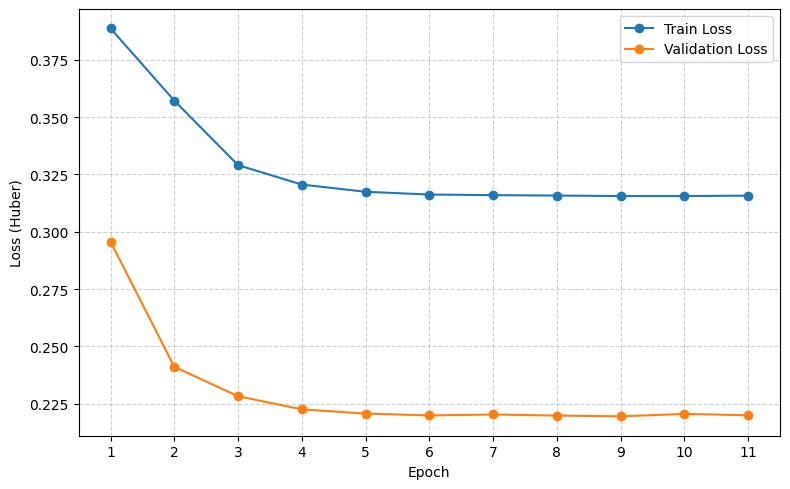

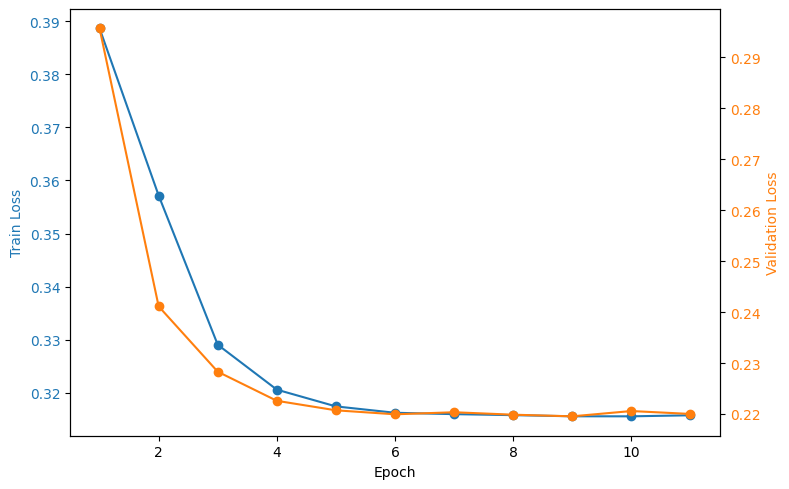

In [5]:
# plot train loss / validation loss
train_loss_history = history.history['loss']
validation_loss_history = history.history['val_loss']
plot_train_validation_loss_by_epoch(train_loss_history, validation_loss_history)
 

In [ ]:
# predict
start = time.time()
y_train_predict = model.predict(X_train)
metrics["train_predict_ms"] = (time.time() - start)
start = time.time()
y_validation_predict = model.predict(X_validation)
metrics["validation_predict_ms"] = (time.time() - start)

start = time.time()
y_test_predict = model.predict(X_test)
metrics["test_predict_ms"] = (time.time() - start)

# append predictions to dataframes 
add_predictions_to_df(df_scaled_window_train, y_train_predict, target_scaler, df_scaled_window_train.iloc[0]["close"])
add_predictions_to_df(df_scaled_window_validation, y_validation_predict, target_scaler, df_scaled_window_validation.iloc[0]["close"])
add_predictions_to_df(df_scaled_window_test, y_test_predict, target_scaler, df_scaled_window_validation.iloc[-1]["predict_close_accumulated"])



763/763 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


In [7]:
# eval metrics
metrics["train"] = evaluate_metrics_df(df_scaled_window_train)
metrics["validation"] = evaluate_metrics_df(df_scaled_window_validation)
metrics["test"] = evaluate_metrics_df(df_scaled_window_test)


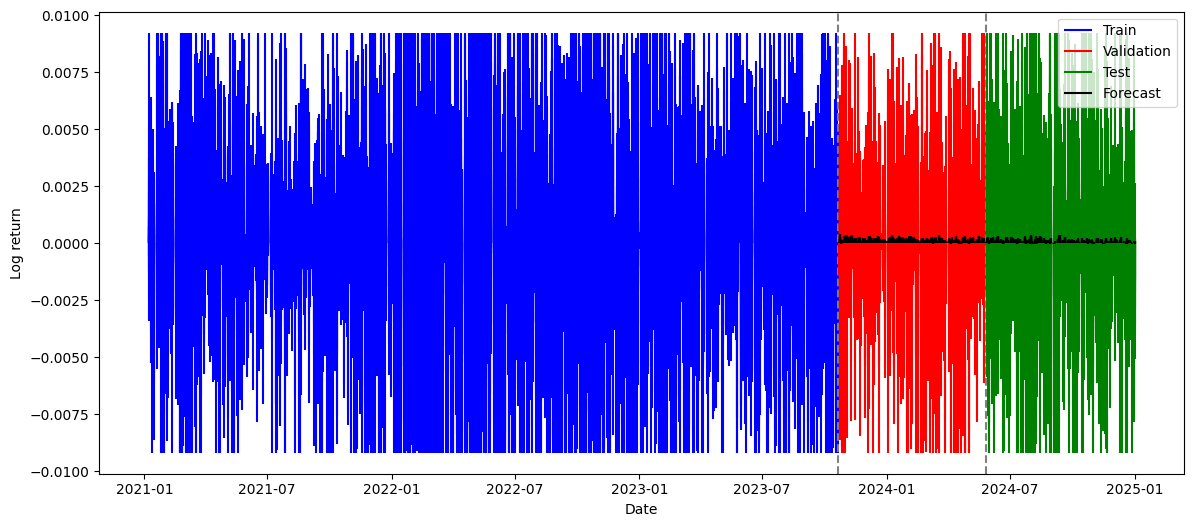

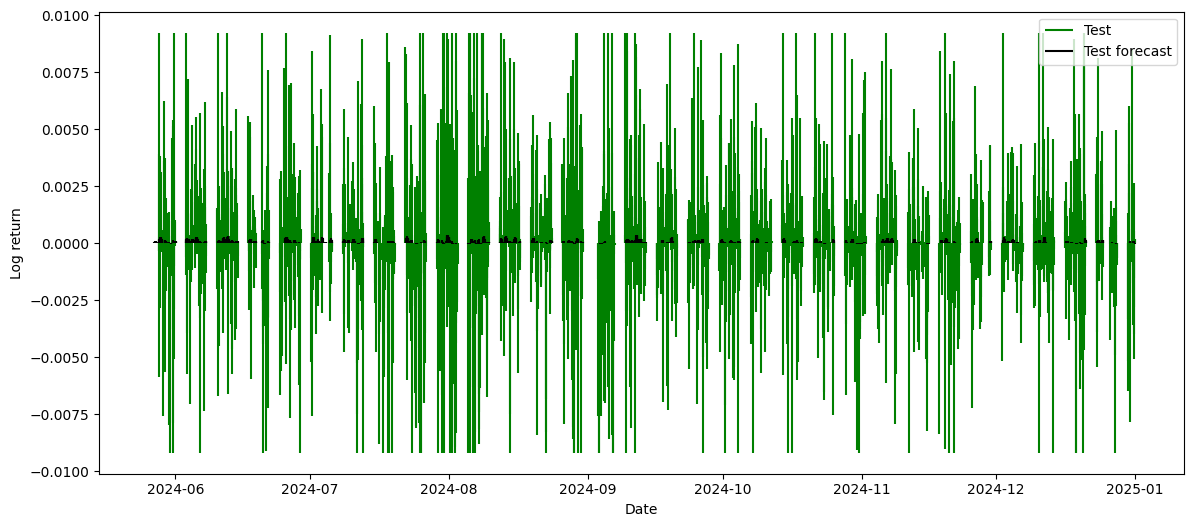

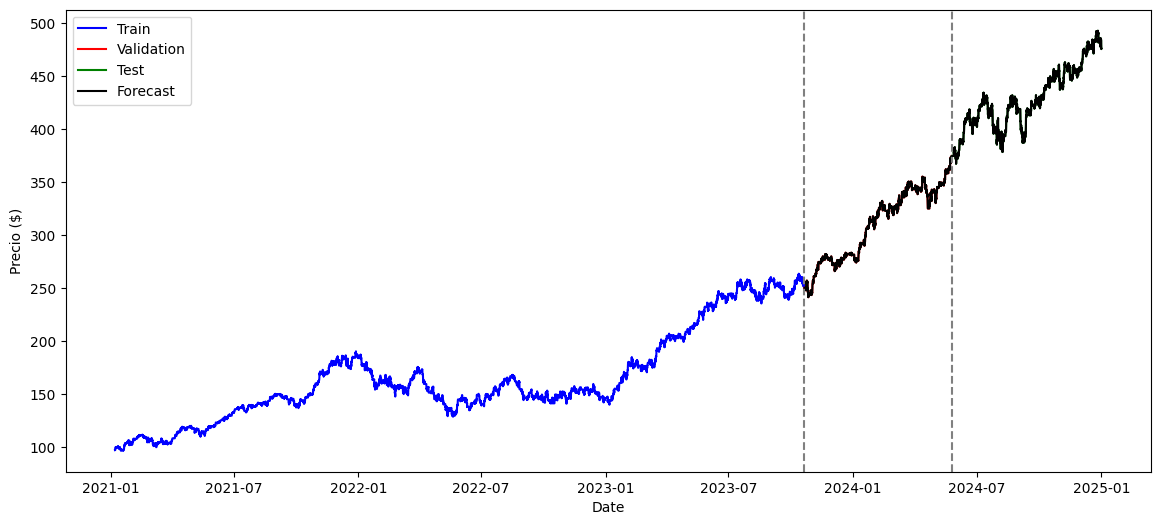

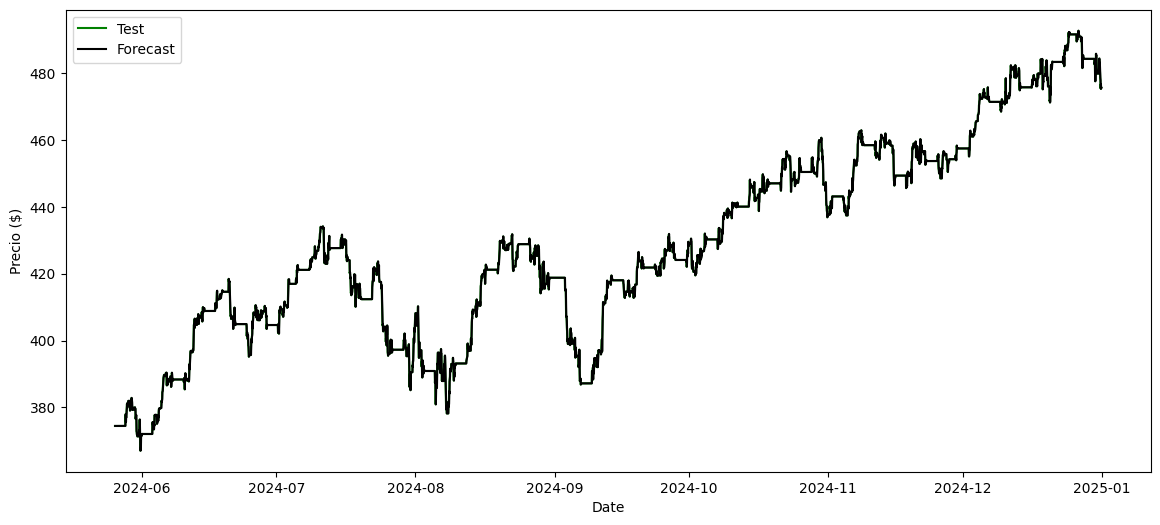

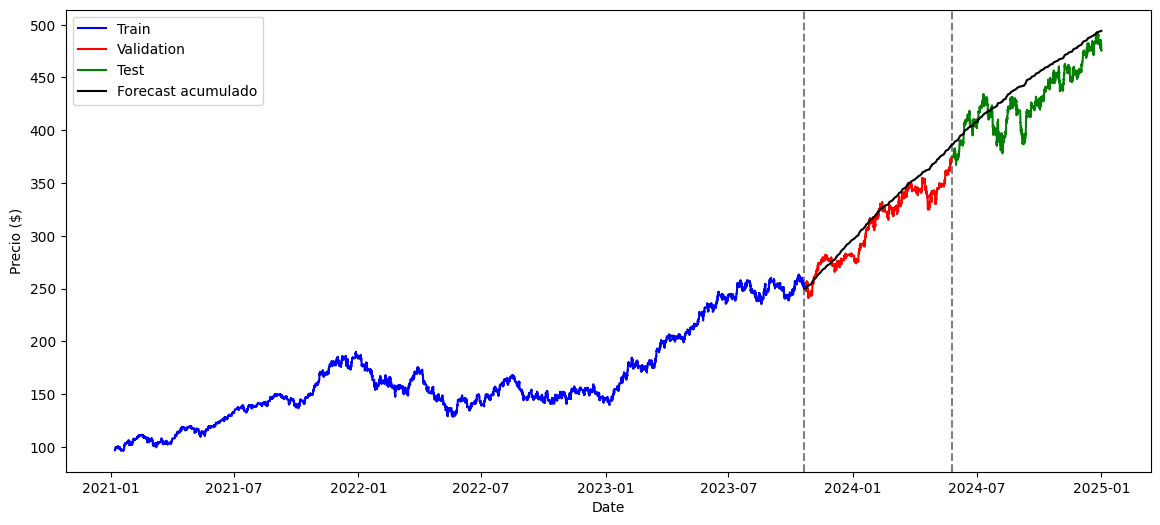

In [8]:
# plot
plot_df(df_scaled_window_train, df_scaled_window_validation, df_scaled_window_test, False)

Confusion Matrix (Counts):
              Pred Down  Pred Neutral  Pred Up
True Down             0           814      269
True Neutral          0          2874      122
True Up               0           872      328 

Confusion Matrix (Percentages):
             Pred Down Pred Neutral Pred Up
True Down         0.0%       75.16%  24.84%
True Neutral      0.0%       95.93%   4.07%
True Up           0.0%       72.67%  27.33%


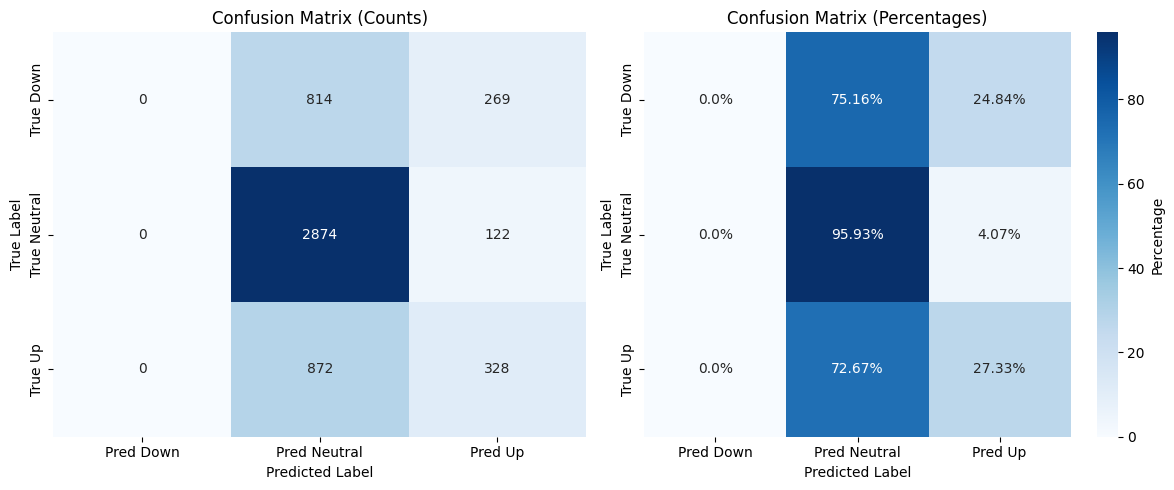

=== Direction Metrics ===
Macro-F1   : 0.368
Weighted-F1: 0.509

Per-class metrics:
Down     | Precision: 0.000 | Recall: 0.000 | F1: 0.000
Neutral  | Precision: 0.630 | Recall: 0.959 | F1: 0.761
Up       | Precision: 0.456 | Recall: 0.273 | F1: 0.342

=== Classification Report ===
              precision    recall  f1-score   support

        Down      0.000     0.000     0.000      1083
     Neutral      0.630     0.959     0.761      2996
          Up      0.456     0.273     0.342      1200

    accuracy                          0.607      5279
   macro avg      0.362     0.411     0.368      5279
weighted avg      0.461     0.607     0.509      5279



D:\Reps\master-ia\10.- Trabajo fin de master\scripts\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Reps\master-ia\10.- Trabajo fin de master\scripts\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Reps\master-ia\10.- Trabajo fin de master\scripts\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

In [9]:
# plot confusion matrix
cm_counts, cm_percent = plot_confusion_matrix(df_scaled_window_test, true_col="target_direction", pred_col="predict_direction")

from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

def print_direction_metrics(df, true_col="target_direction", pred_col="predict_direction"):
    """
    Compute and print precision, recall, and F1 metrics for direction predictions.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing true and predicted labels (-1=Down, 0=Neutral, 1=Up).
    true_col : str
        Column name with true labels.
    pred_col : str
        Column name with predicted labels.
    """

    labels = [-1, 0, 1]
    label_names = ["Down", "Neutral", "Up"]

    y_true = df[true_col]
    y_pred = df[pred_col]

    # Per-class metrics
    precision = precision_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    recall    = recall_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    f1        = f1_score(y_true, y_pred, labels=labels, average=None, zero_division=0)

    # Averages
    macro_f1   = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)

    # Print results
    print("=== Direction Metrics ===")
    print(f"Macro-F1   : {macro_f1:.3f}")
    print(f"Weighted-F1: {weighted_f1:.3f}\n")

    print("Per-class metrics:")
    for i, name in enumerate(label_names):
        print(f"{name:8s} | Precision: {precision[i]:.3f} | Recall: {recall[i]:.3f} | F1: {f1[i]:.3f}")

    print("\n=== Classification Report ===")
    print(classification_report(y_true, y_pred, labels=labels, target_names=label_names, digits=3))

print_direction_metrics(df_scaled_window_test, true_col="target_direction", pred_col="predict_direction")

In [10]:
# Suppose y_dir contains your direction labels (-1, 0, +1)
unique, counts = np.unique(df_scaled_window_test[["target_direction"]].to_numpy(), return_counts=True)
probs = counts / counts.sum()

print("Class distribution TARGET:")
for u, p in zip(unique, probs):
    print(f"{u}: {p:.2%}")

# Suppose y_dir contains your direction labels (-1, 0, +1)
unique, counts = np.unique(df_scaled_window_test[["predict_direction"]].to_numpy(), return_counts=True)
probs = counts / counts.sum()

print("Class distribution PREDICT:")
for u, p in zip(unique, probs):
    print(f"{u}: {p:.2%}")    

Class distribution TARGET:
-1: 20.52%
0: 56.75%
1: 22.73%
Class distribution PREDICT:
0: 86.38%
1: 13.62%


In [11]:
# estabilidad del model

# ANOVA test
anova_result = f_oneway(
    df_scaled_window_train["error_log_return"],
    df_scaled_window_validation["error_log_return"],
    df_scaled_window_test["error_log_return"]
)
metrics["anova"] = anova_result

# show
print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)


F-statistic: 3.168872438667371
p-value: 0.04206308097250892


In [12]:
# show metrics
print(json.dumps(metrics, indent=4) )

{
    "train_ms": 143.87640833854675,
    "train_predict_ms": 11.315053462982178,
    "validation_predict_ms": 2.4004924297332764,
    "test_predict_ms": 2.413914680480957,
    "train": {
        "mse": 6.570881376011294e-06,
        "rmse": 0.0025633730465953047,
        "mae": 0.0012703148662039487,
        "huber": 3.285440688005647e-06,
        "r2": 0.0011650218899064146,
        "mape": null,
        "smape": null,
        "aic": null,
        "bic": null,
        "pearson_r": 0.046644116382587905,
        "spearman_rho": 0.050285472892938714,
        "direction": 57.756289437023675,
        "sharpe": 0.028991205544960662
    },
    "validation": {
        "mse": 4.124849939087811e-06,
        "rmse": 0.002030972658380169,
        "mae": 0.0009819499618044993,
        "huber": 2.0624249695439055e-06,
        "r2": 0.0015755626142482937,
        "mape": null,
        "smape": null,
        "aic": null,
        "bic": null,
        "pearson_r": 0.03996829207215789,
        "spearma

In [13]:
# save 
save_result("LSTM", metrics, df_scaled_window_train, df_scaled_window_validation, df_scaled_window_test)